In [2]:
import math
import glob
import datetime
import xarray as xr
import numpy as np
from scipy import stats
from scipy.signal import correlate
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import os 
import gzip
import shutil
import tempfile
from netCDF4 import Dataset

In [3]:
#Defining open_netcdf function    
def open_netcdf(fname):
    if fname.endswith(".gz"):
        infile = gzip.open(fname, 'rb')
        tmp = tempfile.NamedTemporaryFile(delete=False)
        shutil.copyfileobj(infile, tmp)
        infile.close()
        tmp.close()
        #data = xr.open_dataset(tmp.name)
        data = Dataset(tmp.name)
        os.unlink(tmp.name)
    else:
        #data = xr.open_dataset(fname)
        data = Dataset(fname)
    return data 

#class from Davide Ori
class BinnedPSD():
    """Binned gamma particle size distribution (PSD).

    Callable class to provide a binned PSD with the given bin edges and PSD
    values.

    Args (constructor):
        The first argument to the constructor should specify n+1 bin edges,
        and the second should specify n bin_psd values.

    Args (call):
        D: the particle diameter.

    Returns (call):
        The PSD value for the given diameter.
        Returns 0 for all diameters outside the bins.
    """

    def __init__(self, bin_edges, bin_psd):
        if len(bin_edges) != len(bin_psd)+1:
            raise ValueError("There must be n+1 bin edges for n bins.")

        self.bin_edges = bin_edges
        self.bin_psd = bin_psd

    def psd_for_D(self, D):
        if not (self.bin_edges[0] < D <= self.bin_edges[-1]):
            return 0.0

        # binary search for the right bin
        start = 0
        end = len(self.bin_edges)
        while end-start > 1:
            half = (start+end)//2
            if self.bin_edges[start] < D <= self.bin_edges[half]:
                end = half
            else:
                start = half

        return self.bin_psd[start]

    def __call__(self, D):
        if np.shape(D) == (): # D is a scalar
            return self.psd_for_D(D)
        else:
            return np.array([self.psd_for_D(d) for d in D])

    def __eq__(self, other):
        if other is None:
            return False
        return len(self.bin_edges) == len(other.bin_edges) and             (self.bin_edges == other.bin_edges).all() and             (self.bin_psd == other.bin_psd).all() 

def getEdges():

    pars_class = np.zeros(shape=(32,2))
    bin_edges = np.zeros(shape=(33,1))

    #pars_class[:,0] : Center of Class [mm]
    #pars_class[:,1] : Width of Class [mm]
    pars_class[0:10,1] = 0.125
    pars_class[10:15,1] = 0.250
    pars_class[15:20,1] = 0.500
    pars_class[20:25,1] = 1.
    pars_class[25:30,1] = 2.
    pars_class[30:32,1] = 3.

    j = 0
    pars_class[0,0] = 0.062
    for i in range(1,32):
        if i < 10 or (i > 10 and i < 15) or (i > 15 and i < 20) or (i > 20 and i < 25) or (i > 25 and i < 30) or (i > 30):
            pars_class[i,0] = pars_class[i-1,0] + pars_class[i,1]

        const = [0.188, 0.375, 0.75, 1.5, 2.5]
        if i == 10 or i == 15 or i == 20 or i == 25 or i == 30:
            pars_class[i,0] = pars_class[i-1,0] + const[j]
            j = j + 1

    #print pars_class[i,0]
        bin_edges[i+1,0] = pars_class[i,0] + pars_class[i,1]/2


    bin_edges[0,0] = 0.
    bin_edges[1,0] = pars_class[0,0] + pars_class[0,1]/2 
    
    return bin_edges    


def loadwbandgra(wbandgraFileList):
    wbandgraZe = xr.Dataset()

    #load the files
    for filePath in wbandgraFileList:

        tempDSZe = xr.open_dataset(filePath)

        wbandgraZe = xr.merge([wbandgraZe,
                              tempDSZe])

        tempDSZe.close()
    return wbandgraZe

In [4]:
def histogram_intersection(h1, h2, bins):
   bins = np.diff(bins)
   sm = 0
   for i in range(len(bins)):
       sm += min(bins[i]*h1[i], bins[i]*h2[i])
   return sm

In [5]:
def pars2reflec(filepath_rainscat, parsFilePath, freq, surf_temp, startDate, stopDate): #format='%Y-%m-%d %H:%M'
    # # Parsivel Ze
    freqstr = '%3.1f' % freq
    if (surf_temp < 5):
        scattabstr = '0.C_%sGHz.csv' % freqstr
    elif  (5 <= surf_temp < 15):
        scattabstr = '10C_%sGHz.csv' % freqstr
    else: 
        scattabstr = '20C_%sGHz.csv' % freqstr
        
    filename = os.path.join(filepath_rainscat, scattabstr)     
    print('filename')
    print(filename)
    if os.path.isfile(filename):
        #reading scattering table
        df = pd.read_csv(filename) 
    else:
        print('Error! %s does not exists' % filename)
        return
    diameter = 'diameter[mm]'
    radarxs = 'radarsx[mm2]'
    wavelength = 'wavelength[mm]'
    temp = 'T[k]'
    extxs = 'extxs[mm2]'

    delta = 0.01
    upscale_end = (len(df)+1.)/100.
    diameter_ups = np.arange(delta,upscale_end,delta)

    #constants
    T = df.loc[1,temp]
    wavelen = df.loc[1,wavelength]
    K2 = 0.93

    #integration constant
    int_const = wavelen**4 / ((math.pi)**5 *K2)

    #reding meang volume diameter from parsivel
    print('parsFilePath')
    print(parsFilePath)
    pasrDS = xr.open_dataset(parsFilePath)    
       
    #select time range    
    before=( pd.to_datetime(startDate,format='%Y-%m-%d %H:%M') < pd.to_datetime(pasrDS["time"].data))
    after = ( pd.to_datetime(stopDate,format='%Y-%m-%d %H:%M') > pd.to_datetime(pasrDS["time"].data))
    mask_time = before & after
                          
    if not any(mask_time):
        print('No rain in this user-provided period.')
        return
    else:
        parstime = pasrDS["time"].data[mask_time]
        N = pasrDS['N'][:,mask_time]
        N = 10**N.T
        #print(N)
        
    #calculating Ze using parsivel SD    
    Zpars = np.zeros(N.shape[0])    
    if freq > 20:        
        #Ze parsivel using T-matrix at "freq" GHz
        for i in range(N.shape[0]):
            PSD = BinnedPSD(getEdges(),N[i])                                        
            y = PSD(diameter_ups)*df.loc[:,radarxs]
            Zpars[i] = int_const * y.sum()*delta
    else:
        #Ze parsivel in Rayleigh regime
        for i in range(N.shape[0]):
            PSD = BinnedPSD(getEdges(),N[i])
            d6 = PSD(diameter_ups)*df.loc[:,diameter]**6
            Zpars[i] = d6.sum()*delta 
      
    parsZe = 10 * np.log10(Zpars)
    pars = xr.Dataset({'parsZe': (['time'],  parsZe)}, coords={'time': parstime})
    return pars

def quicklook_radar(figpath, radar, year, month, day, hourstart, minstart):
    matplotlib.rcParams.update({'font.size': 22})
    plt.figure(figsize=(18,5))
    radar['Zg'].T.plot(cmap='jet', vmax=20, vmin=-40)
    plt.grid()
    figstr = '%s%s%s_%s%s_hist_parsZe.png' % (year, month, day, hourstart, minstart)
    plt.savefig(os.path.join(figpath, figstr), dpi=400)

In [6]:
#set date and hour
year='2018'
month='12'
day='23'
hourstart='11'; 
minstart='09'; 
secstart='00'

hourend='12'; 
minend='09'; 
secend='00'

startTime = '%s-%s-%s %s:%s' % (year, month, day, hourstart, minstart)
stopTime = '%s-%s-%s %s:%s' % (year, month, day, hourend, minend)

datestring=year + month + day + '_' + hourstart + minstart + secstart + '-' + hourend + minend + secend

#set vmin vmax 
Ze_vmin=-35
Ze_vmax=25 #35 

In [177]:
# # Data paths
#Parsivel
parsPath = os.path.join('/','data','data_hatpro','jue','data','parsivel','netcdf') 
pathdate = '%s%s' % (year[-2:], month)
parsstr = 'parsivel_jue_%s%s%s.nc' % (year, month, day)
parsFilePath = os.path.join(parsPath, pathdate,  parsstr)

#W-Band (Granada)
wbandgraPath = os.path.join('/','data','optimice','tripex-pol','grarad94','resampled') 
wbandgrastr = '%s%s%s*.nc' % (year, month, day)
wbandgraFilePath = os.path.join(wbandgraPath, wbandgrastr)
wbandgraFileList = glob.glob(wbandgraFilePath)
#mrr_ave-6-0-0-6_nc/1811/181101_jue_mrr_ave-6-0-0-6.nc.gz

#Scattering tables
filepath_rainscat = os.path.join('/','data','optimice','scattering_databases','rain') 

#Save figure
os.path.join('/','data','optimice','scattering_databases','rain') 
figpath = os.path.join('/','data','optimice','granada', 'wradar', 'figures', 'calibration') 

In [7]:
radar  =  xr.open_dataset(r'C:\Users\Usuario\Documents\gitlab\gfatpy\tests\datos\cloudnet\20211217_granada_rpg-fmcw-94.nc')

In [15]:
for variable in [*lidar.variables.keys()]:
    lidar.drop


In [16]:
nc.__version__


'1.6.2'

In [178]:
#Converting parsivel DSD into reflectivity
pars = pars2reflec(filepath_rainscat, parsFilePath, 94, 10, startTime, stopTime)
#pars35 = pars2reflec(filepath_rainscat, parsFilePath, 35.5, 10, startTime, stopTime)
#pars24 = pars2reflec(filepath_rainscat, parsFilePath, 24.1, 10, startTime, stopTime)
#pars10 = pars2reflec(filepath_rainscat, parsFilePath, 10, 10, startTime, stopTime)

filename
/data/optimice/scattering_databases/rain/10C_94.0GHz.csv
parsFilePath
/data/data_hatpro/jue/data/parsivel/netcdf/1812/parsivel_jue_20181223.nc


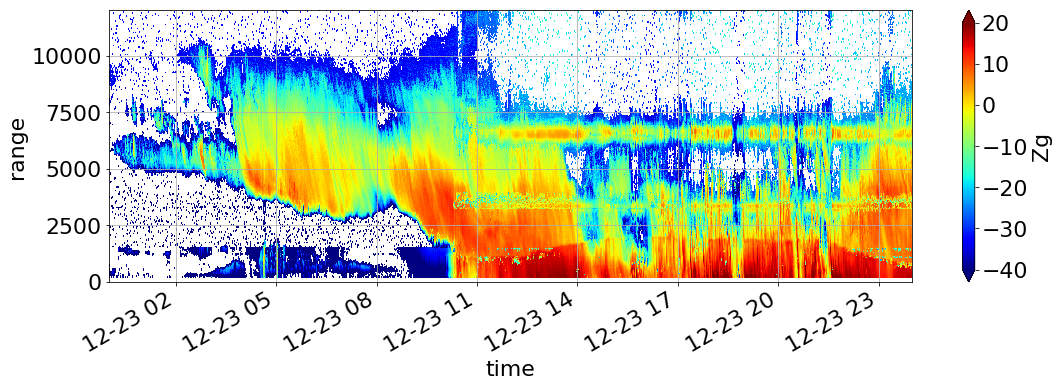

In [179]:
#Loading data from gra wband radar
radar = loadwbandgra(wbandgraFileList)

quicklook_radar(figpath, radar, year, month, day, hourstart, minstart)

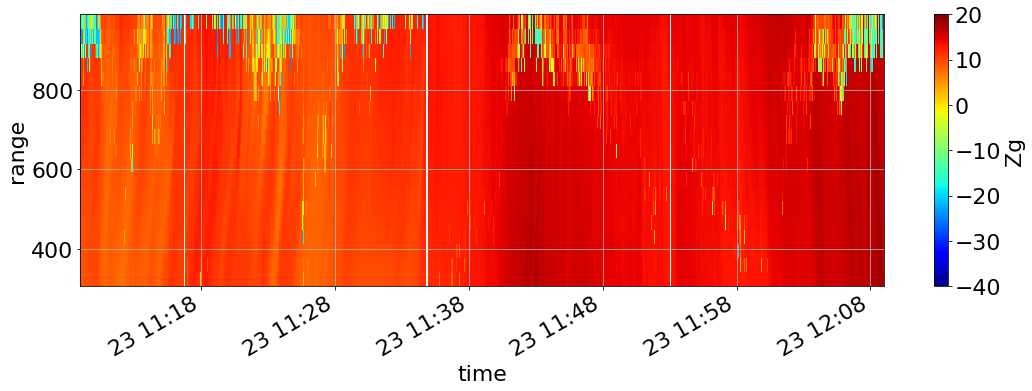

In [180]:
#Selecting reflectitivy of gra wband radar
zref1 = 300
zref2 = 1000
sZe = radar.Zg.sel(time=slice(pd.to_datetime(startTime,format='%Y-%m-%d %H:%M'), pd.to_datetime(stopTime,format='%Y-%m-%d %H:%M')), range=slice(zref1, zref2))
plt.figure(figsize=(18,5))
sZe.T.plot(cmap='jet', vmax=20, vmin=-40)
plt.grid()
#figstr = '%s%s%s_%s%s_hist_parsZe.png' % (year, month, day, hourstart, minstart)
#plt.savefig(os.path.join(figpath, figstr), dpi=400)

In [181]:
sZe = sZe.rolling(time=5,min_periods=4, center=True).mean()
sZe = sZe.interp(time=pars.time)

In [186]:
tmp_binZe = sZe.mean(dim='range')
binZe = tmp_binZe[np.logical_not(np.isnan(tmp_binZe), np.isnan(pars.parsZe.values))]
parsZe = pars.parsZe.values[np.logical_not(np.isnan(tmp_binZe), np.isnan(pars.parsZe.values))]

#Remove low values
reflec_thres = -20
binZe = binZe[binZe > reflec_thres]
parsZe = parsZe[parsZe > reflec_thres]

#Fitting time using linear fit
nsamples = binZe.size
dt = np.arange(1-nsamples, nsamples)
convol = np.convolve(parsZe, binZe)
convolve_shift = dt[convol .argmax()]
print "Convolve time shift: %d" % (convolve_shift)

Convolve time shift: 0


Convolve time shift: 0
Recovered time shift: 0


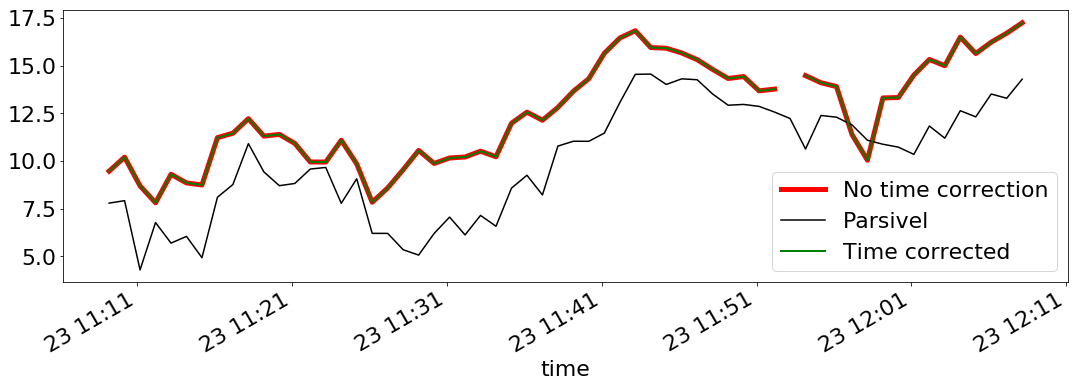

<Figure size 432x288 with 0 Axes>

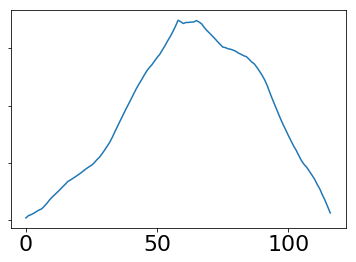

In [199]:
calib_height1 = 300
calib_height2 = 500
binZe = sZe.sel(range=slice(calib_height1, calib_height2 ))
binZe = binZe.mean(dim='range')

#Plot reflectivities
#Radar
plt.figure(figsize=(18,5))
binZe.T.plot(lw=5, color='r', label='No time correction')

#Parsivel
pars.parsZe.T.plot(color='k', label='Parsivel')

#Calibration by direct comparison
number_binZe = binZe.values[np.logical_not(np.isnan(binZe.values), np.isnan(pars.parsZe.values))]
number_parsZe = pars.parsZe.values[np.logical_not(np.isnan(binZe.values), np.isnan(pars.parsZe.values))]

#Remove low values
number_binZe = number_binZe[number_binZe > -20]
number_parsZe = number_parsZe[number_parsZe > -20]

#Fitting time using linear fit
nsamples = norm_binZe.size
dt = np.arange(1-nsamples, nsamples)
a = np.convolve(number_parsZe, number_binZe)
convolve_shift = dt[a.argmax()]
print "Convolve time shift: %d" % (convolve_shift)
nsamples = norm_binZe.size
dt = np.arange(1-nsamples, nsamples)
recovered_time_shift = dt[xcorr.argmax()]
print "Recovered time shift: %d" % (recovered_time_shift)


sbinZe = ssZe.sel(range=slice(calib_height1, calib_height2 ))
sbinZe = sbinZe.mean(dim='range')

#Time shift
sZe = radar.Zg.sel(time=slice(pd.to_datetime(startTime,format='%Y-%m-%d %H:%M'), pd.to_datetime(stopTime,format='%Y-%m-%d %H:%M')), range=slice(zref1, zref2))
sZe = sZe.shift(time=-recovered_time_shift)
sZe = sZe.rolling(time=5,min_periods=4, center=True).mean()
sZe = sZe.interp(time=pars.time)
#Plot reflectivities
#Radar
binZe = sZe.sel(range=slice(calib_height1, calib_height2 ))
binZe = binZe.mean(dim='range')
binZe.T.plot(lw=2, color='g',label='Time corrected')
plt.legend()
plt.show()
#Plot reflectivities after correction
#Radar
figstr = '%s%s%s_%s%s_timeSeries_radarVspars.png' % (year, month, day, hourstart, minstart)
plt.savefig(os.path.join(figpath, figstr), dpi=400)

fig = plt.figure()
# plt.scatter(number_parsZe, number_binZe)
# plt.plot(number_parsZe, line)
ax = fig.gca()
ax.set_yticklabels('')
plt.plot(a)
plt.show()

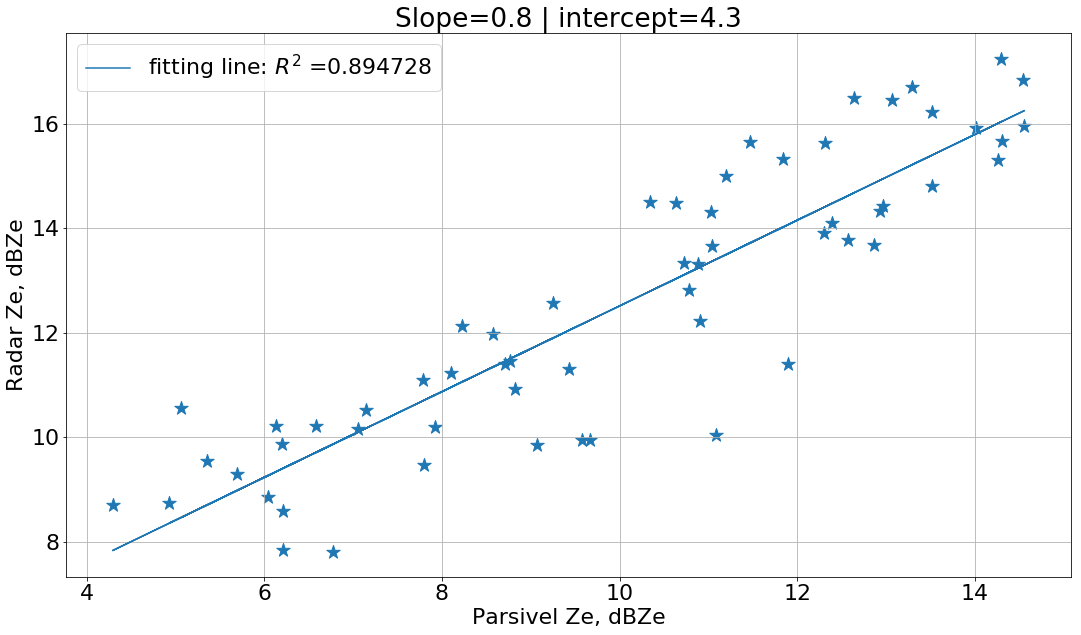

<Figure size 432x288 with 0 Axes>

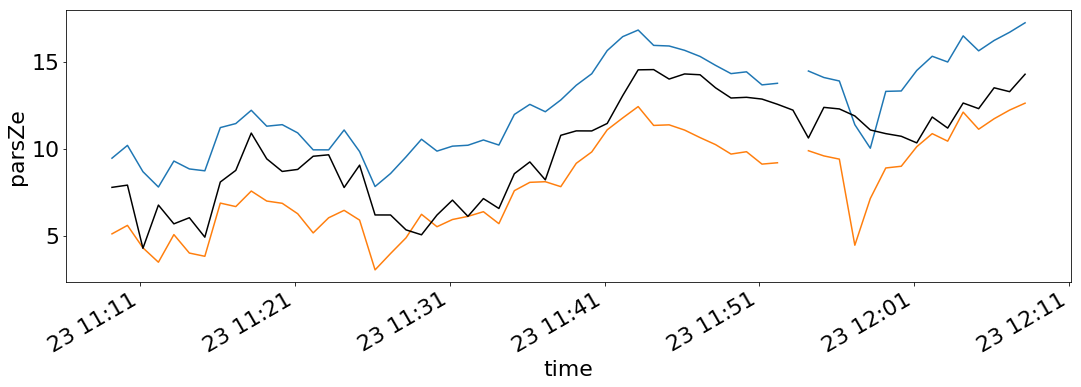

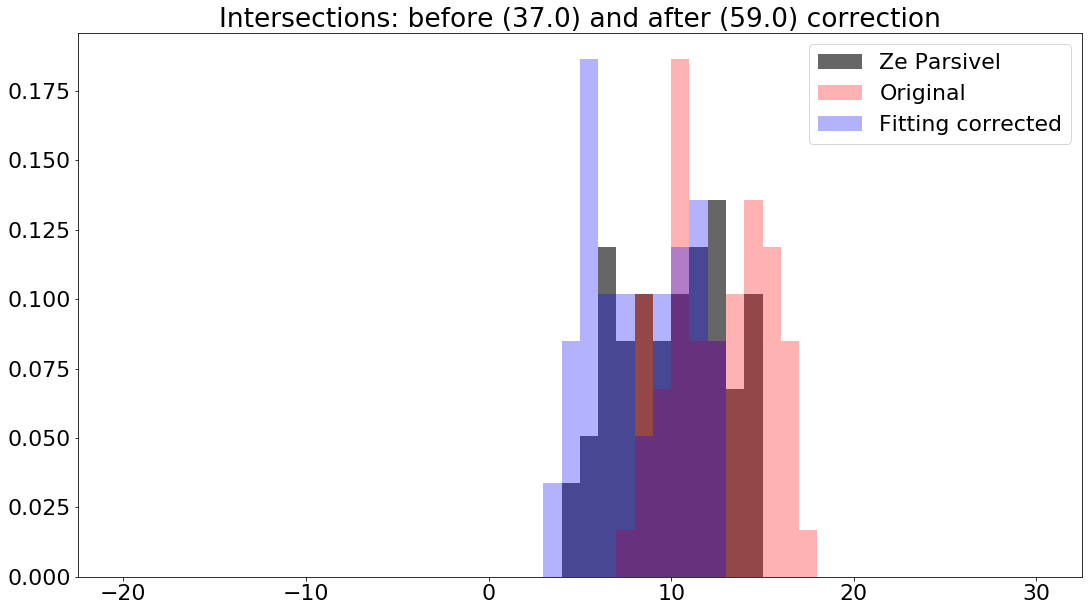

In [157]:
# Generated linear fit
binsZe = sZe.sel(range=slice(calib_height1, calib_height2 ))
binsZe = binsZe.mean(dim='range')

#Calibration by direct comparison
number_binsZe = binsZe.values[np.logical_not(np.isnan(binsZe.values), np.isnan(pars.parsZe.values))]
number_parsZe = pars.parsZe.values[np.logical_not(np.isnan(binsZe.values), np.isnan(pars.parsZe.values))]

#Remove low values
number_binZe = number_binZe[number_binZe > -20]
number_parsZe = number_parsZe[number_parsZe > -20]

slope, intercept, r_value, p_value, std_err = stats.linregress(number_parsZe, number_binsZe)
line = slope*number_parsZe+intercept

fit_shift = -intercept

plt.figure(figsize=(18,10))
plt.scatter(number_parsZe, number_binsZe, s=200, marker='*')
strleg= 'fitting line: $R^2$ =%f' % (r_value)
plt.plot(number_parsZe, line, label=strleg)
plt.xlabel('Parsivel Ze, dBZe')
plt.ylabel('Radar Ze, dBZe')
plt.title('Slope=%3.1f | intercept=%3.1f' % (slope, intercept))
plt.legend()
plt.grid()
plt.show()
figstr = '%s%s%s_%s%s_fit_radarVspars.png' % (year, month, day, hourstart, minstart)
plt.savefig(os.path.join(figpath, figstr), dpi=400)

#Correction
fradar = number_binsZe + fit_shift

#Radar
plt.figure(figsize=(18,5))  
binZe.T.plot()
binZe2.T.plot()
pars.parsZe.T.plot(color='k')
#Parsivel
plt.show()

#Comparison of histograms
rawhist, bin_edges = np.histogram(number_binsZe, bins=50, range=[-20, 30])        
parshist, bin_edges = np.histogram(number_parsZe, bins=50, range=[-20, 30])        
fhist, bin_edges = np.histogram(fradar, bins=50, range=[-20, 30])        
raw_isec= histogram_intersection(rawhist,parshist,bin_edges)
fit_isec= histogram_intersection(fradar,parshist,bin_edges)

plt.figure(figsize=(18,10))
#Plot Parsivel
plt.hist(arrayparsZe, bins=50, range=[-20, 30],
         normed=1, facecolor='k',
         alpha=0.6, label='Ze Parsivel')
#Plot original Radar histogram
plt.hist(arrayZe, bins=50, range=[-20, 30],
         normed=1, facecolor='r',
         alpha=0.3, label='Original')
#Plot Corrected Radar according to the intersection
plt.hist(fradar, bins=50, range=[-20, 30],
         normed=1, facecolor='b',
         alpha=0.3, label='Fitting corrected')
plt.title('Intersections: before (%3.1f) and after (%3.1f) correction' % ( raw_isec2, fit_isec ))
plt.legend()
plt.show()
# figstr = '%s%s%s_%s%s_hist_radarVspars_FittingCorrection.png' % (year, month, day, hourstart, minstart)
# plt.savefig(os.path.join(figpath, figstr), dpi=400)

In [114]:
calib_height1 = 400
calib_height2 = 500
binZe = sZe.sel(range=slice(calib_height1, calib_height2 ))
binZe = binZe.mean(dim='range')

#Calibration by direct comparison
number_binZe = binZe.values[np.logical_not(np.isnan(binZe.values), np.isnan(pars.parsZe.values))]
number_parsZe = pars.parsZe.values[np.logical_not(np.isnan(binZe.values), np.isnan(pars.parsZe.values))]

#Remove low values
number_binZe = number_binZe[number_binZe > -20]
number_parsZe = number_parsZe[number_parsZe > -20]

#Shift according to Median
median_shift = np.median(number_parsZe)-np.median(number_binZe)
mradar = number_binZe + median_shift

rawhist, bin_edges = np.histogram(number_binZe, bins=50, range=[-20, 30])        
medianhist, bin_edges = np.histogram(mradar, bins=50, range=[-20, 30])        
parshist, bin_edges = np.histogram(number_parsZe, bins=50, range=[-20, 30])        
raw_isec= histogram_intersection(rawhist,parshist,bin_edges)
median_isec= histogram_intersection(medianhist,parshist,bin_edges)

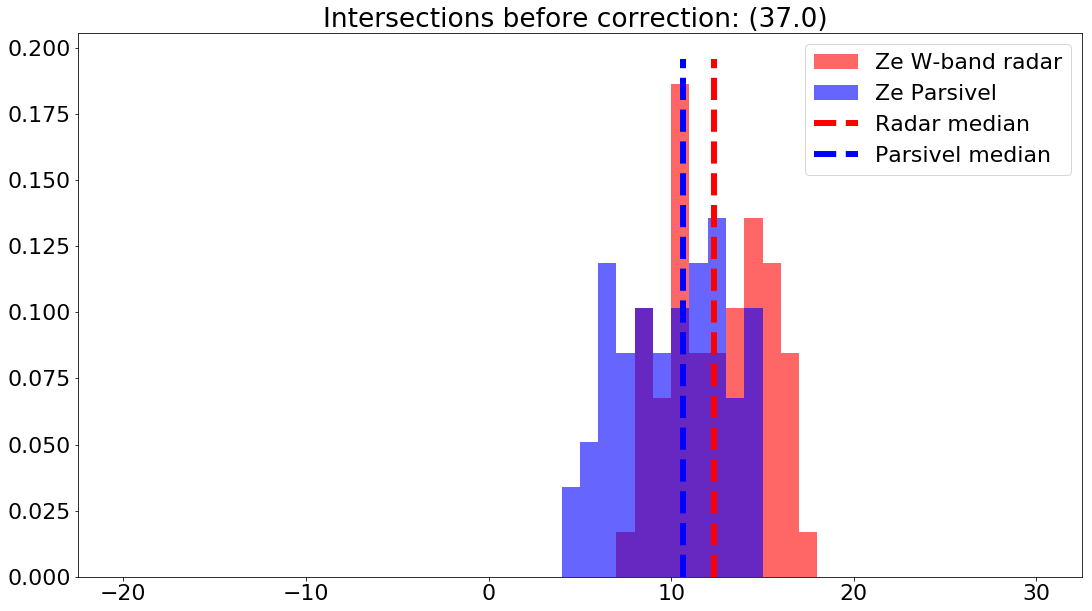

<Figure size 432x288 with 0 Axes>

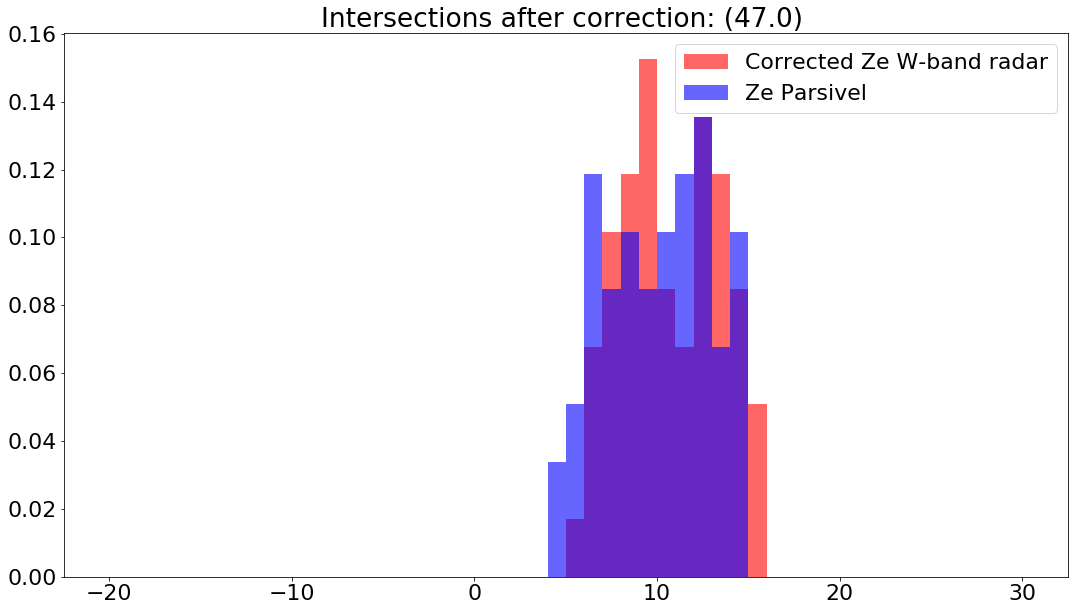

<Figure size 432x288 with 0 Axes>

In [115]:
#Plot reflectivities
#Radar
matplotlib.rcParams.update({'font.size': 22})
plt.figure(figsize=(18,10))
plt.hist(number_binZe, bins=50, range=[-20, 30],
         normed=1, facecolor='r',
         alpha=0.6, label='Ze W-band radar')
#Parsivel
binning = plt.hist(number_parsZe, bins=50, range=[-20, 30],
         normed=1, facecolor='b',
         alpha=0.6, label='Ze Parsivel')
axes = plt.gca()
limits = axes.get_ylim()
#Plot median Radar
plt.vlines(np.median(number_binZe), limits[0], limits[1], color='r', linestyles='dashed', linewidth=6, label='Radar median')
#Plot median Parsivel 
plt.vlines(np.median(number_parsZe), limits[0], limits[1], color='b', linestyles='dashed', linewidth=6, label='Parsivel median')
plt.title('Intersections before correction: (%3.1f) ' % raw_isec)
plt.legend()
plt.show()
figstr = '%s%s%s_%s%s_hist_radarVspars.png' % (year, month, day, hourstart, minstart)
plt.savefig(os.path.join(figpath, figstr), dpi=400)

plt.figure(figsize=(18,10))
plt.hist(mradar, bins=50, range=[-20, 30],
         normed=1, facecolor='r',
         alpha=0.6, label='Corrected Ze W-band radar')
#Parsivel
binning = plt.hist(number_parsZe, bins=50, range=[-20, 30],
         normed=1, facecolor='b',
         alpha=0.6, label='Ze Parsivel')
axes = plt.gca()
limits = axes.get_ylim()
plt.title('Intersections after correction: (%3.1f) ' % median_isec)
plt.legend()
plt.show()
figstr = '%s%s%s_%s%s_hist_radarVspars_medianCorrection.png' % (year, month, day, hourstart, minstart)
plt.savefig(os.path.join(figpath, figstr), dpi=400)

In [ ]:
# nshape = sZe.shape
# print(nshape[1])
# colors = cm.rainbow(np.linspace(0, 1, nshape[1]))
# plt.figure(figsize=(18,10))
# for n in xrange(nshape[1]):
#     tmp = sZe[~np.isnan(sZe[:,n]),n]    
#     legstr = 'Ze W-band radar at %d m.' %  sZe.range[n]
#     plt.hist(tmp, bins=50, range=[-20, 30], normed=1, facecolor=colors[n,:], alpha=0.2, label=legstr)
# #Parsivel
# #plt.hist(arrayparsZe, bins=50,
# #         normed=1, facecolor='k',
# #         alpha=0.6, label='Ze Parsivel')
# plt.legend(fontsize=10)
# plt.xlabel('Reflectivity, $dBZ_e$')
# plt.ylabel('Frequency, #')
# plt.grid()
# plt.show()

In [ ]:
# nshape = sZe.shape
# nrange = nshape[1]
# medianZe = np.empty(nrange)
# for n in xrange(nshape[1]):    
#     tmp = sZe[~np.isnan(sZe[:,n]),n]  
#     medianZe[n] = tmp.median()

# plt.figure(figsize=(18,10))
# plt.scatter(sZe.range,medianZe, label='Radar', s=200, marker='p')
# plt.scatter(0, np.median(arrayparsZe), label='Parsivel', s=200, marker='o')
# plt.xlabel('Range, m', fontsize=24)
# plt.ylabel('Ze, $dBZ_e$', fontsize=24)
# plt.legend()
# plt.grid()
# plt.show()

# matplotlib.rcParams.update({'font.size': 22})

# plt.figure(figsize=(18,10))
# difZe = medianZe-np.median(arrayparsZe)
# plt.scatter(sZe.range, difZe, s=200, marker='*')
# plt.xlabel('Range, m', fontsize=24)
# plt.ylabel('$Ze[radar]_{median} - Ze[parsivel]_{median}$', fontsize=24)
# plt.grid()
# plt.show()

In [ ]:
# # fitmedian = difZe[:]
# fitrange = sZe.range[:]

# # Generated linear fit
# slope, intercept, r_value, p_value, std_err = stats.linregress(fitrange,fitmedian)
# line = slope*fitrange+intercept

# plt.figure(figsize=(18,10))
# difZe = medianZe-np.median(arrayparsZe)
# plt.scatter(sZe.range, difZe, s=200, marker='*', label='DiffZe')
# strleg= 'fitting line: $R^2$ =%f' % (r_value)
# print(strleg)
# plt.plot(fitrange, line, label=strleg)
# plt.xlabel('Range, m')
# plt.ylabel('$\Delta$Ze')
# plt.legend()
# plt.grid()
# plt.show()

In [116]:
binsize = 50
calib_height1 = 400
calib_height2 = 500
binZe = sZe.sel(range=slice(calib_height1, calib_height2 ))
binZe = binZe.mean(dim='range')

#Calibration by direct comparison
arrayZe = binZe.values[np.logical_not(np.isnan(binZe.values), np.isnan(pars.parsZe.values))]
arrayparsZe = pars.parsZe.values[np.logical_not(np.isnan(binZe.values), np.isnan(pars.parsZe.values))]

#Remove low values
arrayZe = arrayZe[arrayZe > -20]
arrayparsZe = arrayparsZe[arrayparsZe > -20]

vshift = np.arange(-5,5,0.1)
isec = np.zeros(vshift.size)
hfix, bin_edges = np.histogram(arrayparsZe, bins=binsize, range=[-20, 30])
rawhist2, bin_edges = np.histogram(arrayZe, bins=binsize, range=[-20, 30])        
raw_isec2 = histogram_intersection(rawhist2,hfix,bin_edges)
median_isec2 = histogram_intersection(mradar,hfix,bin_edges)
idx = -1
for shift in vshift:    
    idx = idx + 1 
    hshift, bin_edges = np.histogram(arrayZe+shift, bins=binsize, range=[-20, 30])        
    isec[idx] = histogram_intersection(hshift,hfix,bin_edges)
inter_isec = np.max(isec)
#print(np.max(isec)==isec)
selshift = vshift[np.max(isec)==isec]
#print(selshift.mean())

In [117]:
#Shift according to Intersection
intersec_shift = selshift.mean()
iradar = arrayZe + intersec_shift
print('Correction by intersection %f' % intersec_shift)
print('Correction by median %f' % median_shift)

Correction by intersection -2.333333
Correction by median -1.726247


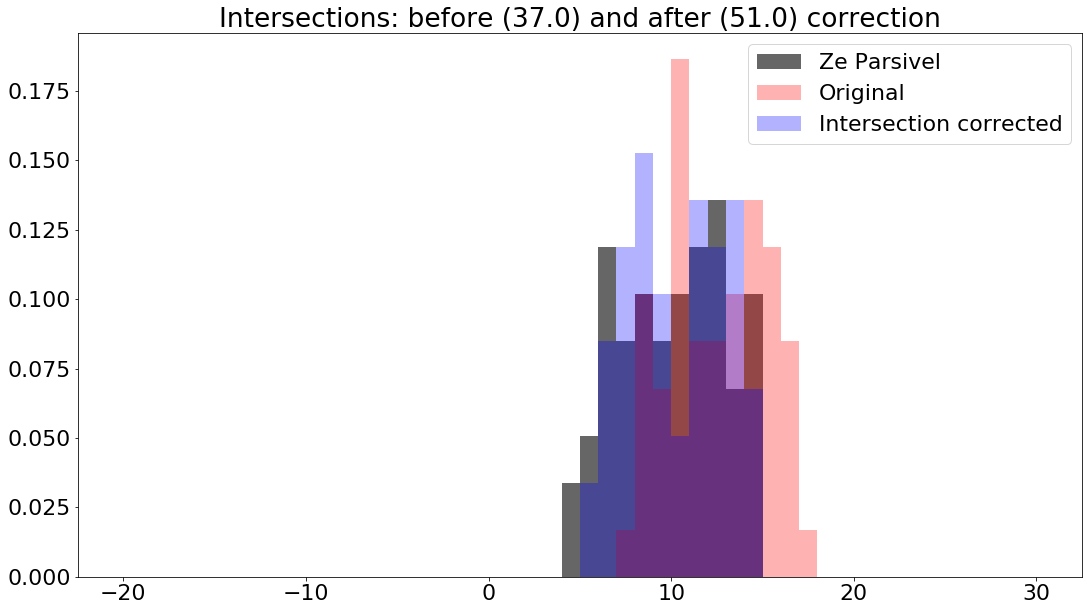

<Figure size 432x288 with 0 Axes>

In [122]:
plt.figure(figsize=(18,10))
#Plot Parsivel
plt.hist(arrayparsZe, bins=50, range=[-20, 30],
         normed=1, facecolor='k',
         alpha=0.6, label='Ze Parsivel')
#Plot original Radar histogram
plt.hist(arrayZe, bins=50, range=[-20, 30],
         normed=1, facecolor='r',
         alpha=0.3, label='Original')
#Plot Corrected Radar according to the intersection
plt.hist(iradar, bins=50, range=[-20, 30],
         normed=1, facecolor='b',
         alpha=0.3, label='Intersection corrected')
plt.title('Intersections: before (%3.1f) and after (%3.1f) correction' % ( raw_isec2, inter_isec ))
plt.legend()
plt.show()
figstr = '%s%s%s_%s%s_hist_radarVspars_IntersecCorrection.png' % (year, month, day, hourstart, minstart)
plt.savefig(os.path.join(figpath, figstr), dpi=400)

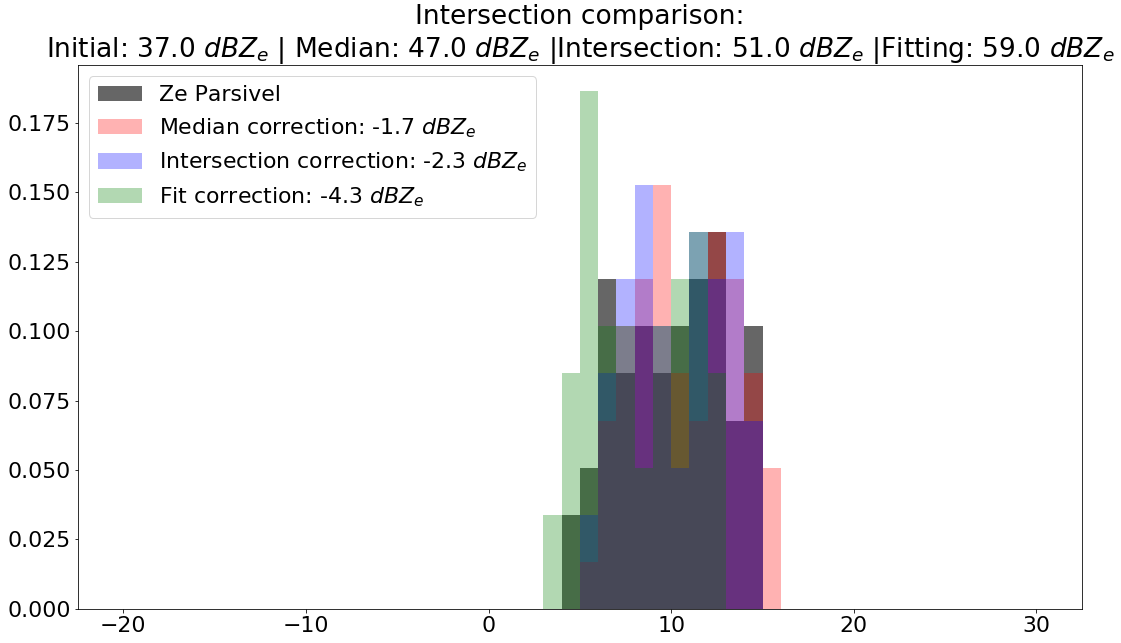

<Figure size 432x288 with 0 Axes>

In [162]:
plt.figure(figsize=(18,10))
#Plot Parsivel
plt.hist(arrayparsZe, bins=50, range=[-20, 30],
         normed=1, facecolor='k',
         alpha=0.6, label='Ze Parsivel')
#Plot original Radar histogram
plt.hist(mradar, bins=50, range=[-20, 30],
         normed=1, facecolor='r',
         alpha=0.3, label='Median correction: %3.1f $dBZ_e$' % median_shift)
#Plot Corrected Radar according to the intersection
plt.hist(iradar, bins=50, range=[-20, 30],
         normed=1, facecolor='b',
         alpha=0.3, label='Intersection correction: %3.1f $dBZ_e$' % intersec_shift)
#Plot Corrected Radar according to the intersection
plt.hist(fradar, bins=50, range=[-20, 30],
         normed=1, facecolor='g',
         alpha=0.3, label='Fit correction: %3.1f $dBZ_e$' % fit_shift)
title_str = 'Intersection comparison:\nInitial: %3.1f $dBZ_e$ | Median: %3.1f $dBZ_e$ |Intersection: %3.1f $dBZ_e$ |Fitting: %3.1f $dBZ_e$' % ( raw_isec2, median_isec ,inter_isec, fit_isec)
plt.title(title_str)
plt.legend()
plt.show()
figstr = '%s%s%s_%s%s_hist_radarVspars_CorrectionComparison.png' % (year, month, day, hourstart, minstart)
plt.savefig(os.path.join(figpath, figstr), dpi=400)